In [22]:
import numpy as np
import matplotlib.pyplot as plt
import re

import os

In [23]:
from src.utils import _isotope_to_element, _isotope_label, _combine_elements
from src.plot import plot_yields
from src.load_data import load_ishigaki, load_hw2002, load_ishigaki_selected
from params import filter_elements, f_star_by_f_dil
from src.salvadori_funcs import salvadori_Zism, salvadori_abundance_ratio, salvadori_H_ratio
from src.salvadori_funcs import salvadori_yields as salvadori_yields_convert
from src.formulas import abundance_ratio


In [24]:
ishigaki18_yields = load_ishigaki()
hw_yields = load_hw2002()
ishigaki18_selected_yields = load_ishigaki_selected() # NOTE: already summed isotopes

In [25]:
ishigaki18_selected_yields = [entry for entry in ishigaki18_selected_yields if entry["params"]["mass"] in [13, 15, 25, 40]]

In [26]:
hw_yields = hw_yields[1:]

# for entry in hw_yields:
#     entry['yields'] = _combine_elements(entry['yields'])

In [27]:
salvadori_yields = salvadori_yields_convert(ishigaki18_selected_yields)

for entry in salvadori_yields:
    entry['yields'] = _combine_elements(entry['yields'])

print("Salvadori Yields:")
print(salvadori_yields[0])

print("HW2002 Yields:")
print(hw_yields[0])

Salvadori Yields:
{'label': 'M=13', 'params': {'mass': 13.0, 'energy': 1.0, 'Mcut': 1.25, 'MCO': 2.39, 'Mout': 0.2, 'lfej': -1.1}, 'yields': {'H': 0.5073298461538461, 'He': 0.3092031538461538, 'Li': 1.6728461538461537e-11, 'Be': 1.3642307692307693e-21, 'B': 2.2620223076923077e-17, 'C': 0.005697544615384615, 'N': 0.0, 'O': 0.03458706153846154, 'F': 9.212307692307693e-12, 'Ne': 0.0011759076923076922, 'Na': 1.1084615384615384e-05, 'Mg': 0.006647973076923077, 'Al': 0.0002905877692307692, 'Si': 0.00635033, 'S': 0.0018498638461538462, 'Cl': 4.653584615384615e-06, 'Ar': 0.0002544280769230769, 'K': 6.419979230769231e-07, 'Ca': 0.00022888069230769228, 'Sc': 1.9796923076923075e-09, 'Ti': 9.709223076923077e-06, 'V': 2.5131546153846154e-06, 'Cr': 7.926376923076923e-05, 'Mn': 1.035e-05, 'Fe': 0.012890700000000001, 'Co': 3.2554615384615384e-05, 'Ni': 0.0006981815384615385, 'Cu': 1.0066315384615384e-06, 'Zn': 2.260964615384615e-05, 'Ga': 1.3431853846153848e-09, 'Ge': 2.6276253846153846e-09}}
HW2002 Y

(0.0001, [(13.0, np.float64(-5.3897234986370535)), (13.0, np.float64(-19.667397753487013)), (13.0, np.float64(-6.223773347658669)), (13.0, np.float64(-9.177229199341847)), (13.0, np.float64(-5.363294551724316)), (13.0, np.float64(-6.205452552594771)), (13.0, np.float64(-8.877232279779724)), (40.0, np.float64(-6.1199720149313634)), (40.0, np.float64(-5.974198430139529)), (40.0, np.float64(-5.891400431403259)), (40.0, np.float64(-5.712570522319508)), (40.0, np.float64(-5.629204849933993)), (40.0, np.float64(-5.579638320853801)), (40.0, np.float64(-6.262672520453194)), (40.0, np.float64(-6.098280748892849)), (40.0, np.float64(-5.998294914041182)), (40.0, np.float64(-5.843117564746114)), (40.0, np.float64(-5.782715708212077)), (40.0, np.float64(-5.643106996643528)), (40.0, np.float64(-6.3626695507261335)), (40.0, np.float64(-6.143106659947316)), (40.0, np.float64(-6.043122150346788)), (40.0, np.float64(-6.09691381176083)), (40.0, np.float64(-5.923747648962475)), (40.0, np.float64(-5.743106

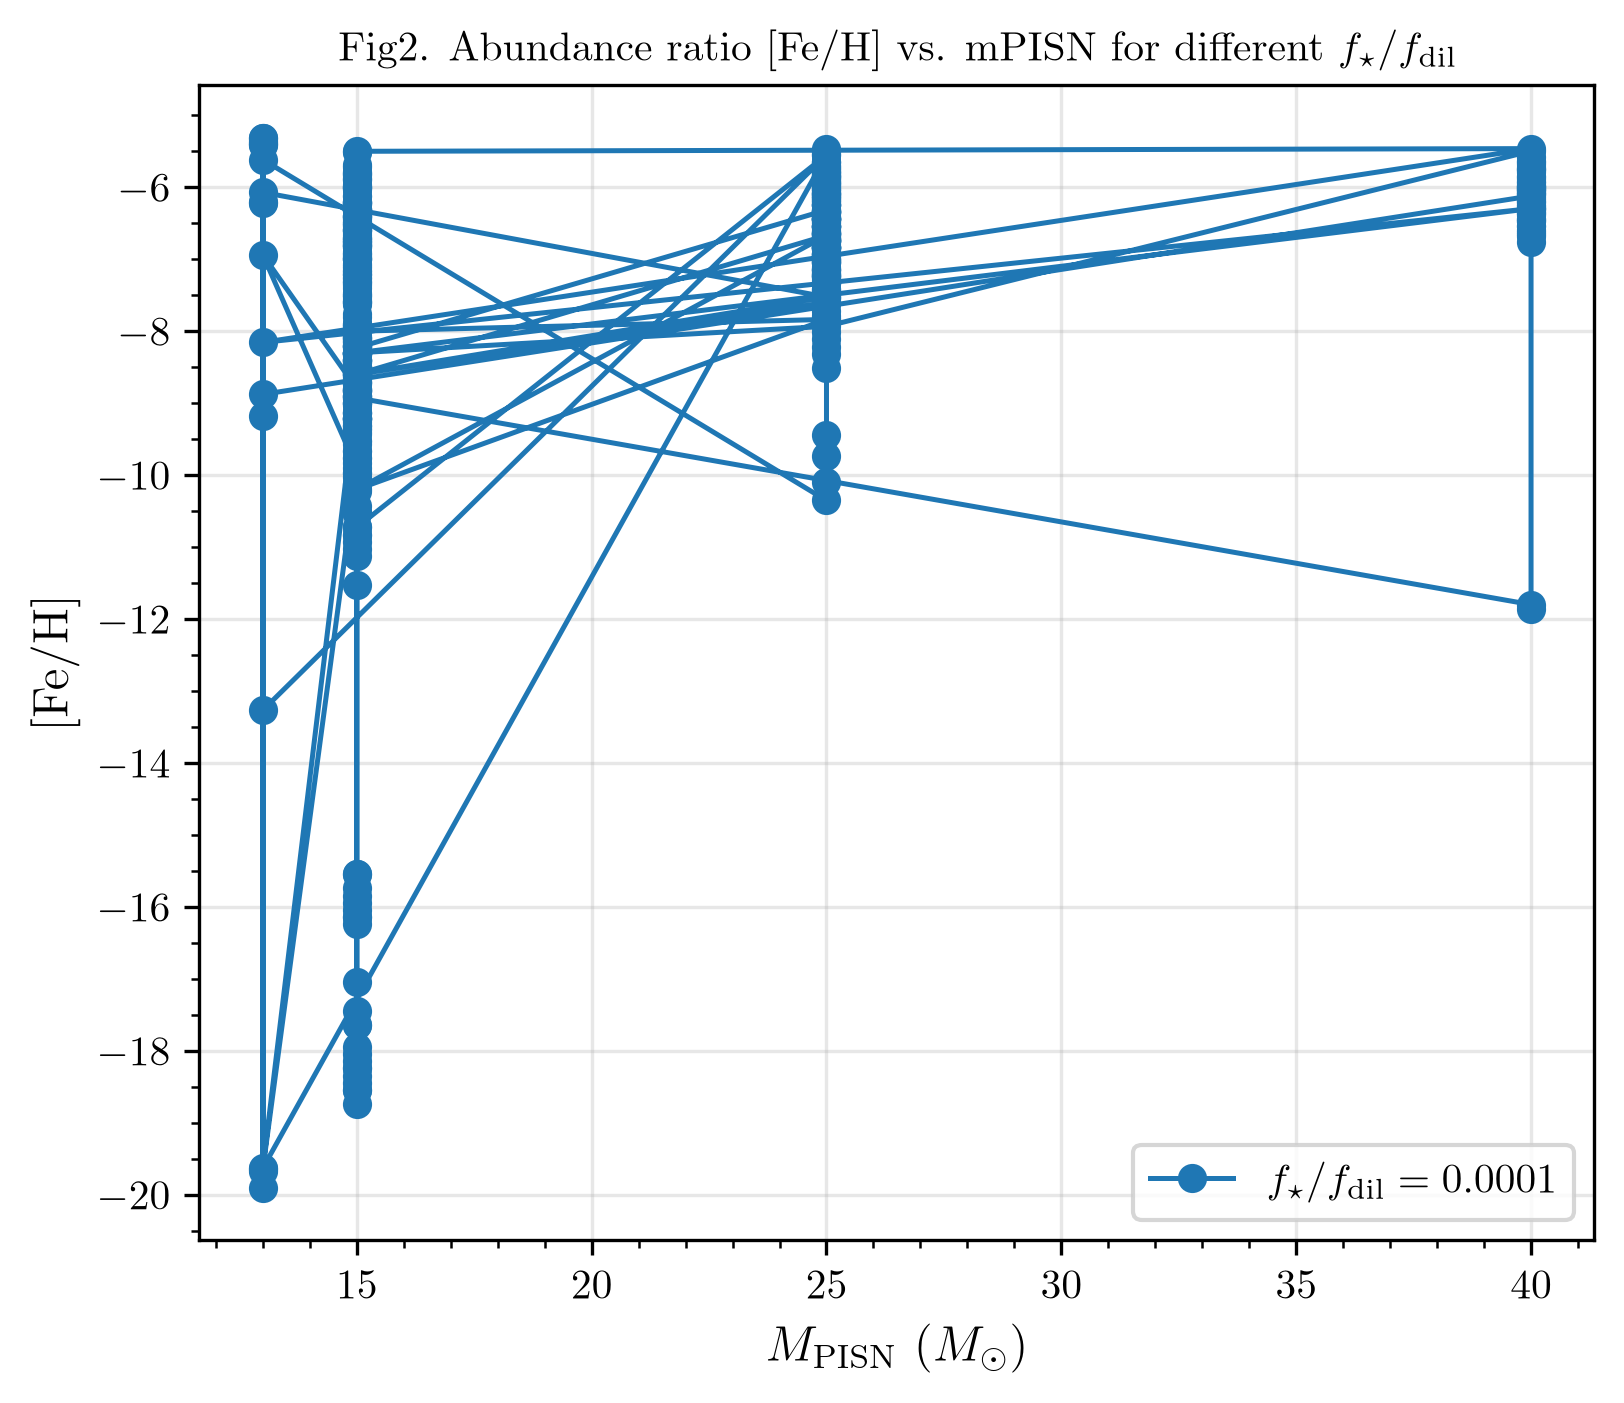

In [33]:
f_star_by_f_dil = [1e-4, 1e-3, 1e-2, 1e-1]

Zism = {}
for f in f_star_by_f_dil:
    Zism[f] = salvadori_Zism(f, salvadori_yields)

fig2_values = []
for f in Zism:
    f_ratio = f
    yield_data = Zism[f]

    Fe_H_to_mPISN = []
    for y in yield_data:
        mass = y['params']['mass']
        Fe = y['yields']['Fe']
        H = y['yields']['H']

        Fe_H = salvadori_H_ratio('Fe', f_ratio, y)

        Fe_H_to_mPISN.append((mass, Fe_H))

    fig2_values.append((f_ratio, Fe_H_to_mPISN))

print(fig2_values[0])
print(fig2_values[1])

fig, ax = plt.subplots(figsize=(6, 5))

for f_ratio, Fe_H_to_mPISN in fig2_values:
    masses = np.array([m for m, _ in Fe_H_to_mPISN])
    fe_h = np.array([r for _, r in Fe_H_to_mPISN])
    ax.plot(masses, fe_h, marker="o", linewidth=1.2,
            label=rf"$f_\star/f_\mathrm{{dil}} = {f_ratio:g}$")
    break

ax.set_xlabel(r"$M_\mathrm{PISN}\ (M_\odot)$")
ax.set_ylabel(r"$[\mathrm{Fe}/\mathrm{H}]$")
ax.legend()
ax.grid(True, alpha=0.3)
plt.minorticks_on()
plt.title(r"Fig2. Abundance ratio $[\mathrm{Fe}/\mathrm{H}]$ vs. mPISN for different $f_\star/f_\mathrm{dil}$", fontsize=10)
plt.show()


In [29]:
# ishigaki_yields = [
#     e for e in ishigaki18_yields if
#     # e["params"]["lfej"] == 0.0
#     # and
#     e["params"]["mass"] == 25
# ] 

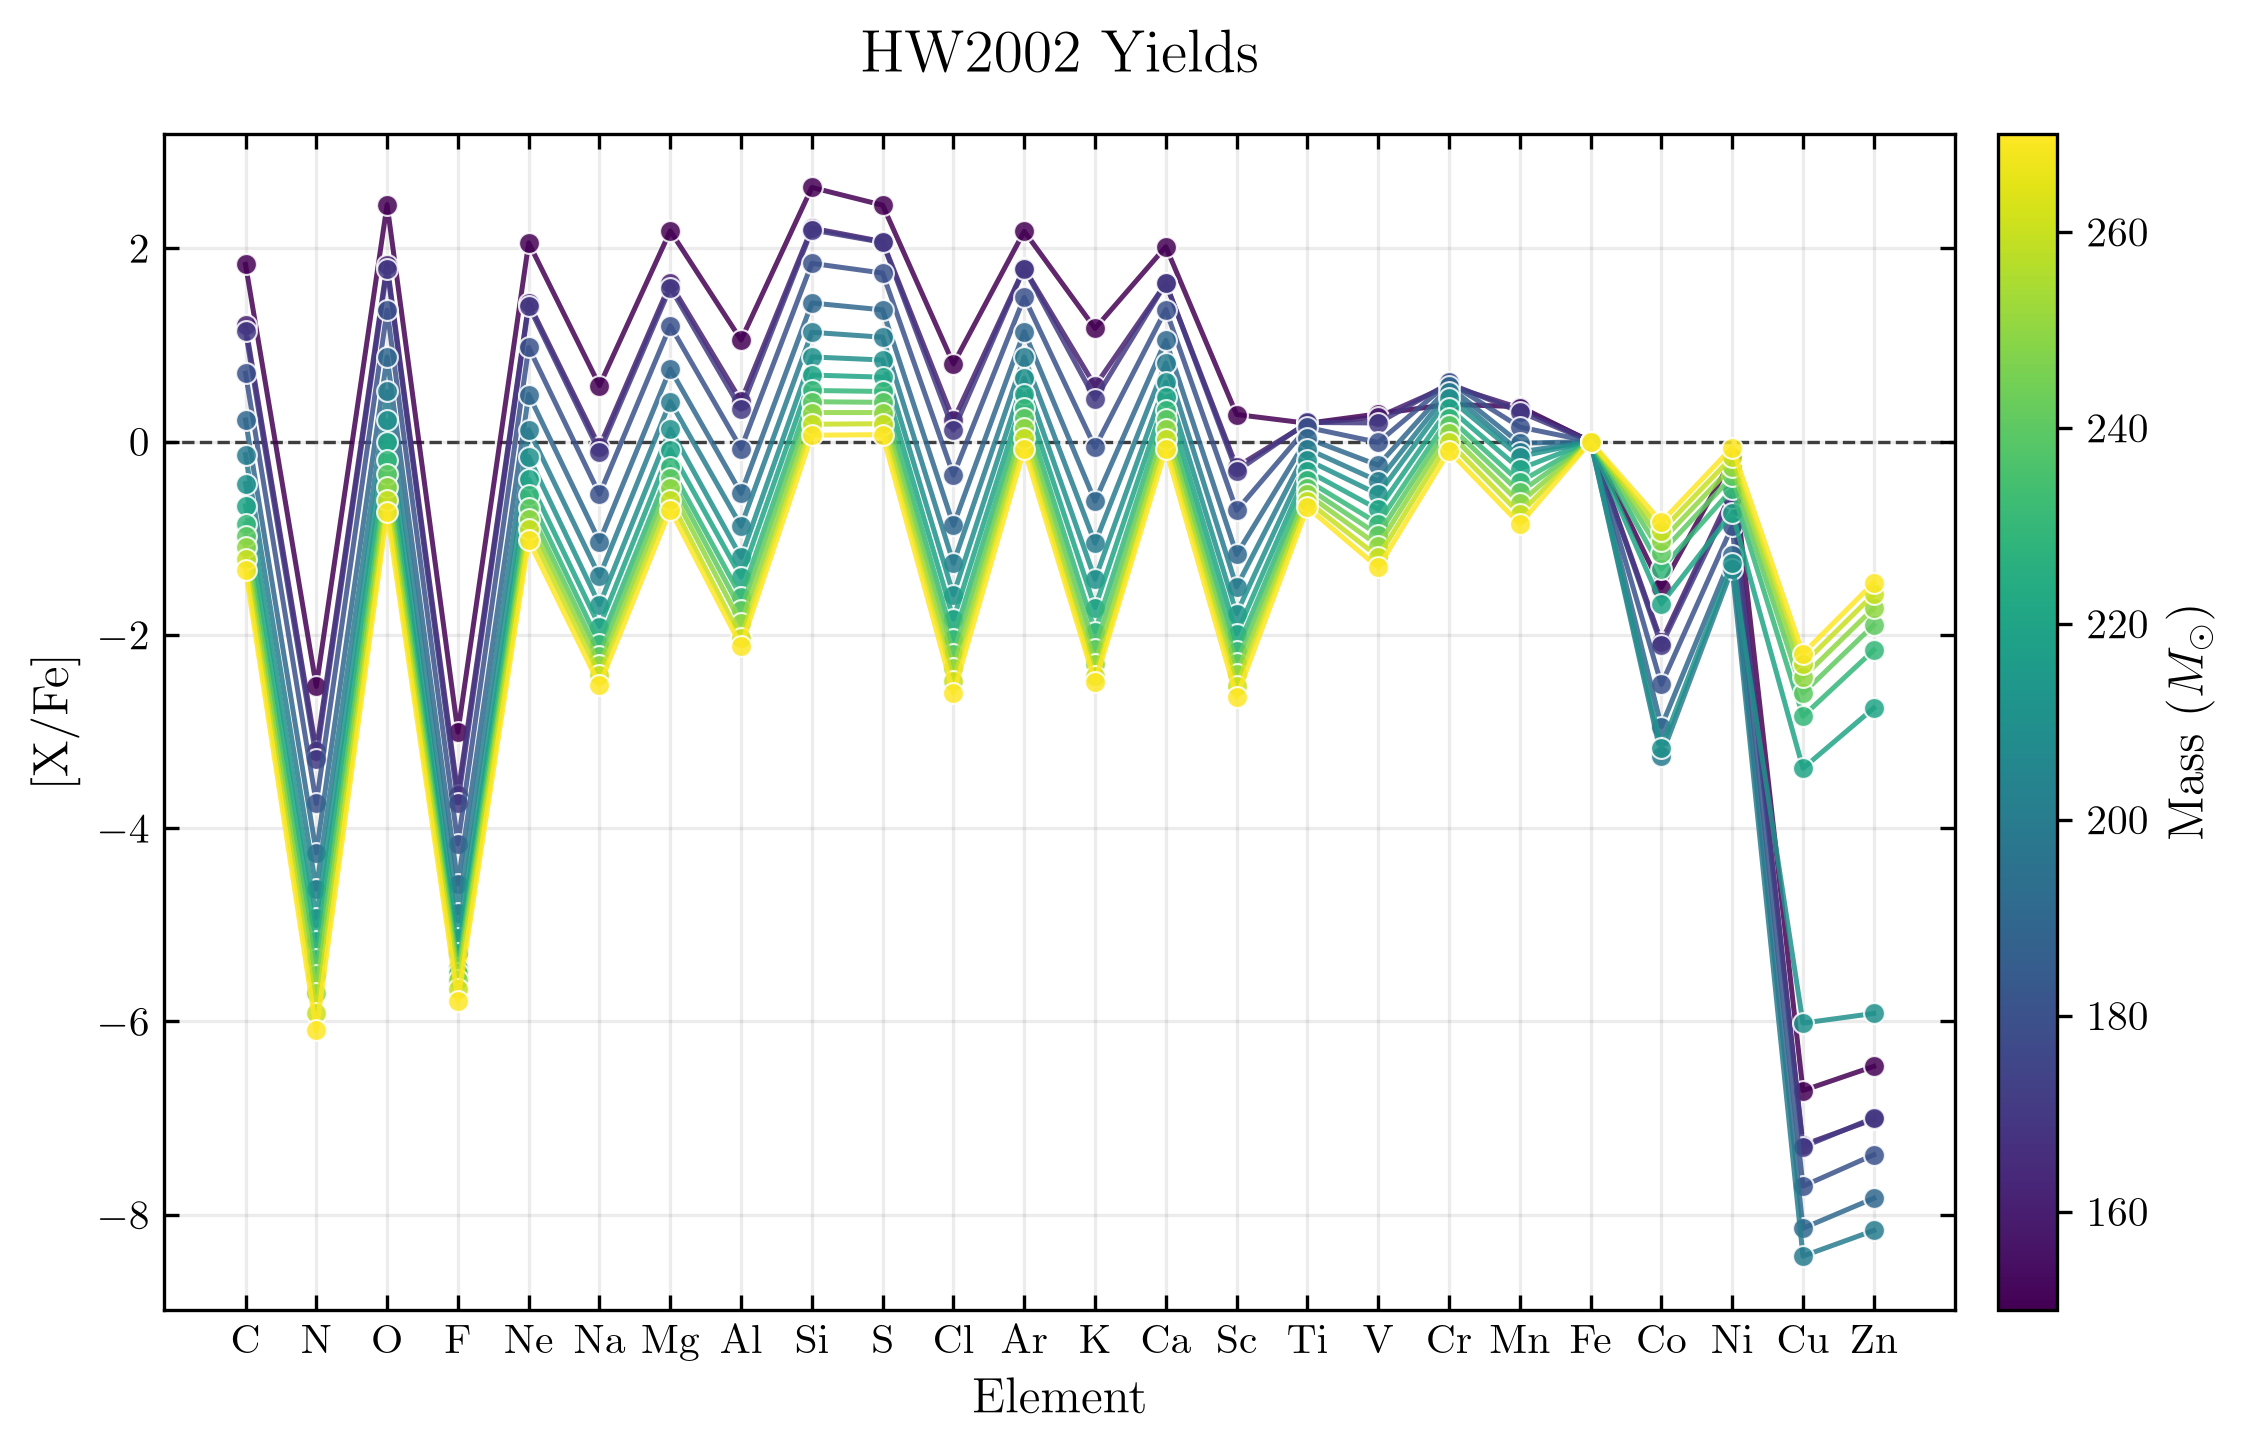

In [30]:
plot_yields(hw_yields, title="HW2002 Yields", combine_elements=True, filter_elements=filter_elements)

/home/ardo/mlem/Vaults/Thesis/Repl/src/formulas.py:36: RuntimeWarning: divide by zero encountered in log10
  abundance_ratio = np.log10((mass1 / atomic_mass[elem1]) / (mass2 / atomic_mass[elem2])) - (A1 - A2)


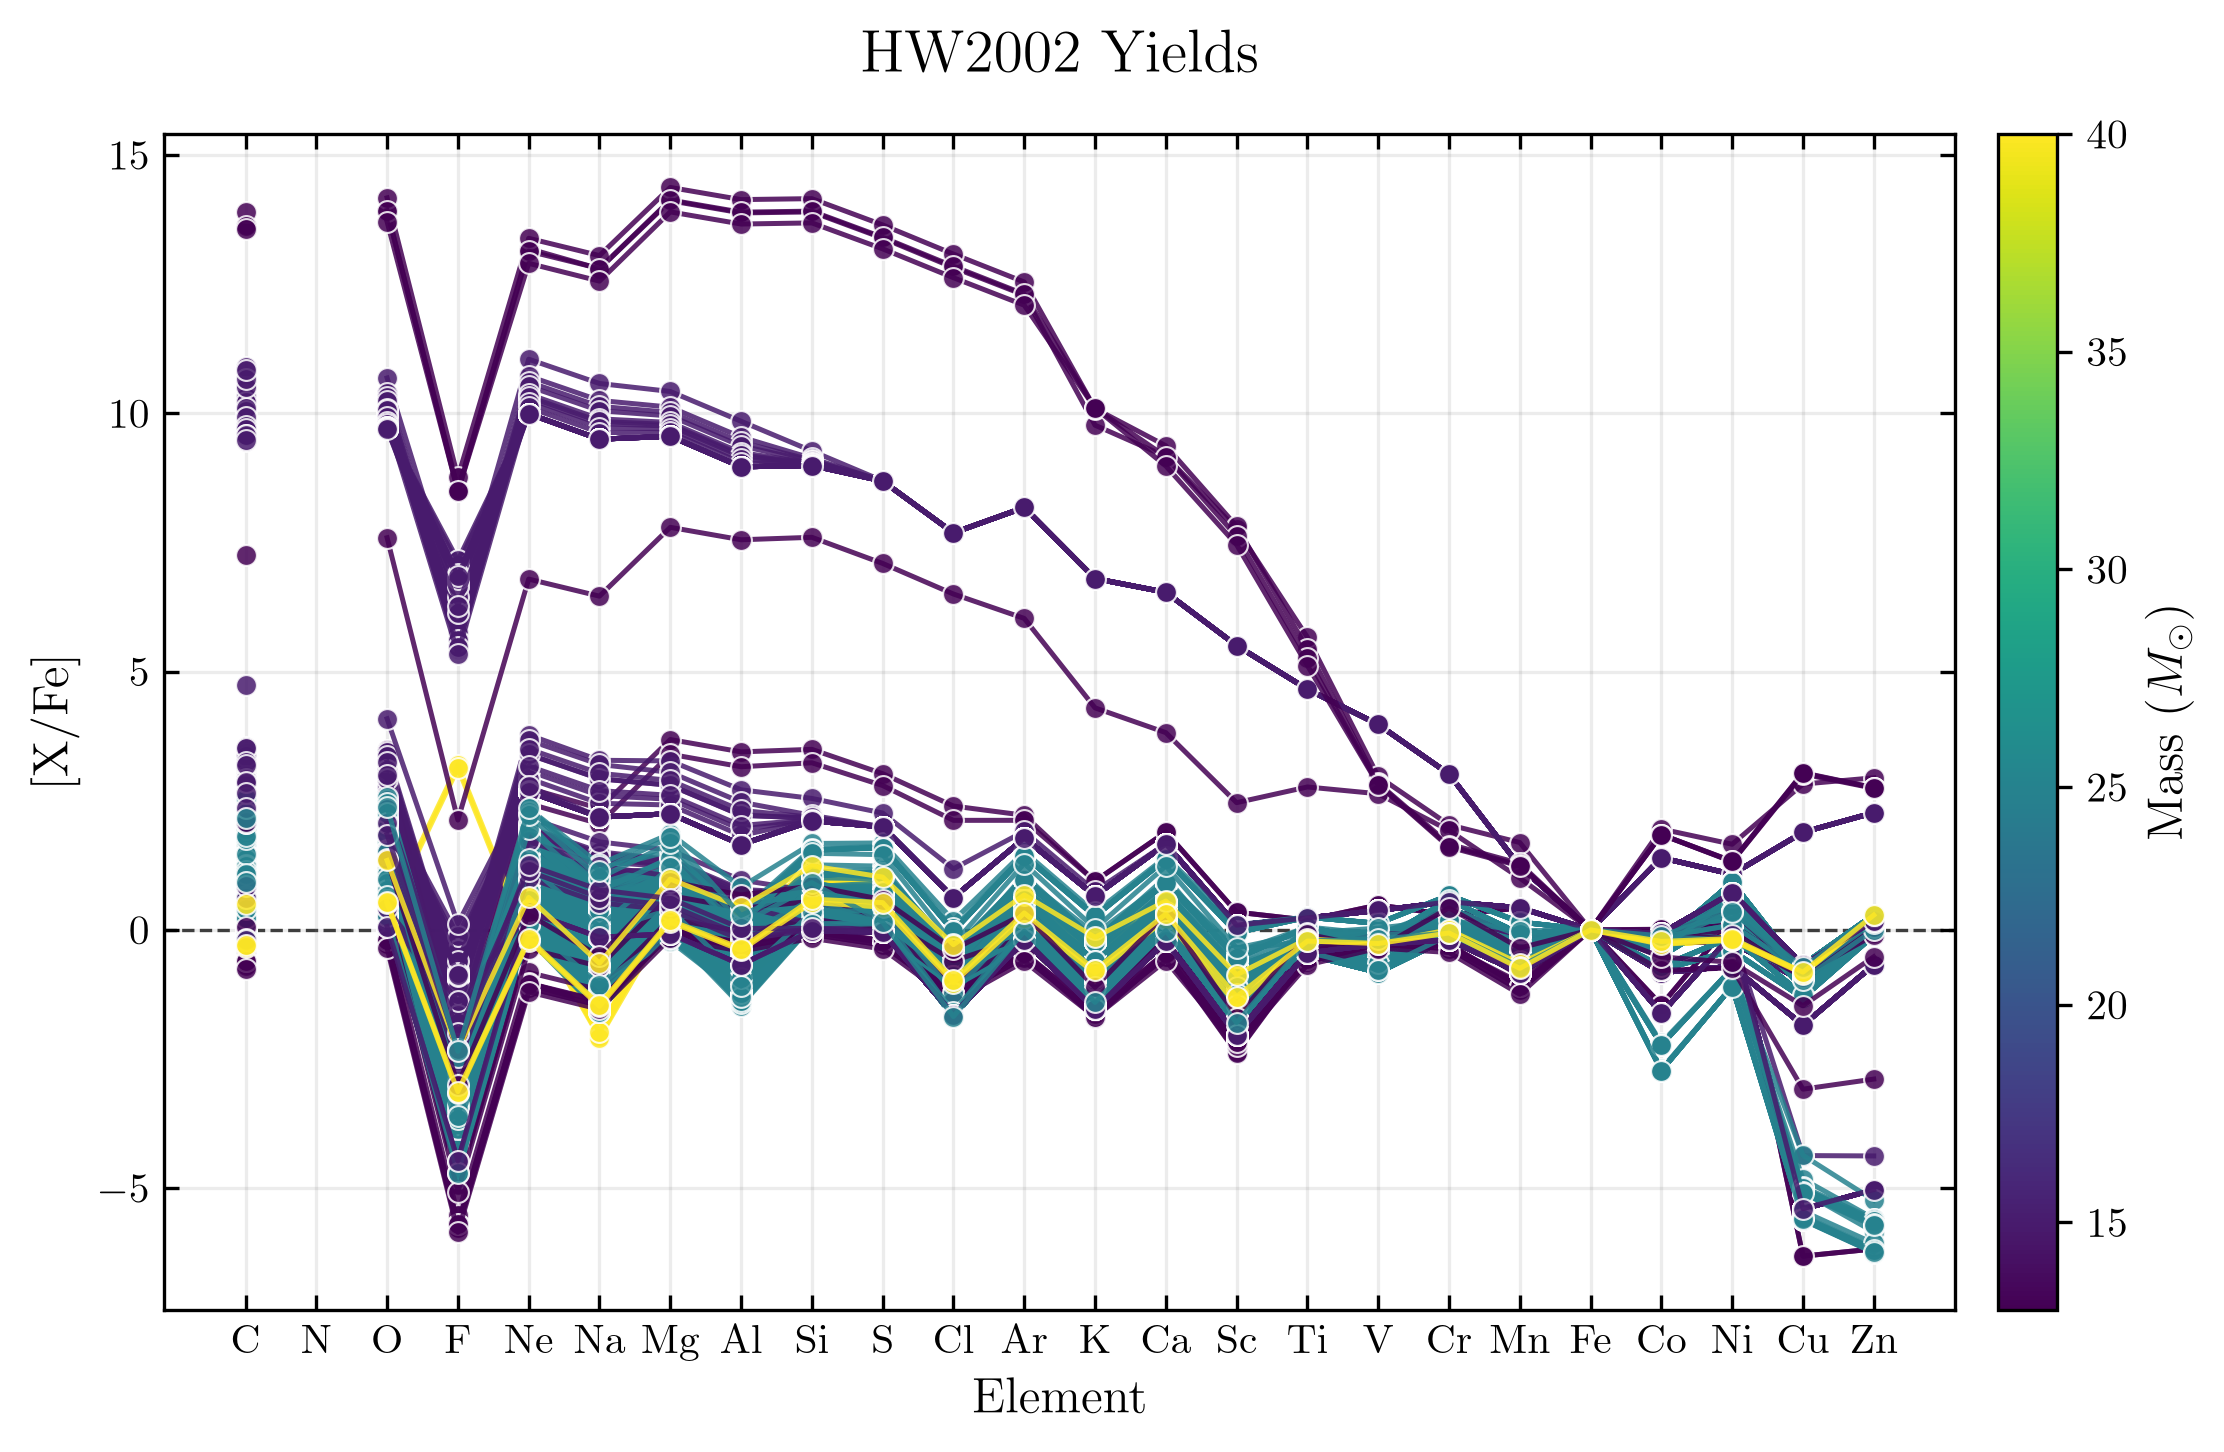

In [31]:
plot_yields(salvadori_yields, title="HW2002 Yields", combine_elements=True, filter_elements=filter_elements)

In [32]:
# plot_yields(ishigaki_yields, title="Ishigaki 2018 Yields", combine_elements=True, filter_elements=filter_elements)